## Problem 1: Portfolio Construction & Daily Returns

### a) Create `prices_df`, compute daily percentage returns, and display the returns matrix.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

data = {
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}
days = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6']

prices_df = pd.DataFrame(data, index=days)
print("--- Prices DataFrame ---")
print(prices_df)

returns_df = prices_df.pct_change()
print("\n--- Daily Returns Matrix ---")
print(returns_df)

--- Prices DataFrame ---
       RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day 1      2800  1450      1600         520
Day 2      2850  1470      1580         535
Day 3      2830  1460      1610         528
Day 4      2900  1490      1625         540
Day 5      2880  1510      1615         555
Day 6      2950  1500      1640         548

--- Daily Returns Matrix ---
       RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day 1       NaN       NaN       NaN         NaN
Day 2  0.017857  0.013793 -0.012500    0.028846
Day 3 -0.007018 -0.006803  0.018987   -0.013084
Day 4  0.024735  0.020548  0.009317    0.022727
Day 5 -0.006897  0.013423 -0.006154    0.027778
Day 6  0.024306 -0.006623  0.015480   -0.012613


### b) Compute units purchased on Day 1 and calculate daily portfolio value vectorially. Plot the portfolio value.

Units purchased for each asset on Day 1:
  RELIANCE: 89.2857 units
  INFY: 172.4138 units
  HDFCBANK: 156.2500 units
  TATAMOTORS: 480.7692 units

Daily Portfolio Values:
Day 1    1.000000e+06
Day 2    1.011999e+06
Day 3    1.009811e+06
Day 4    1.029347e+06
Day 5    1.036658e+06
Day 6    1.041725e+06
dtype: float64


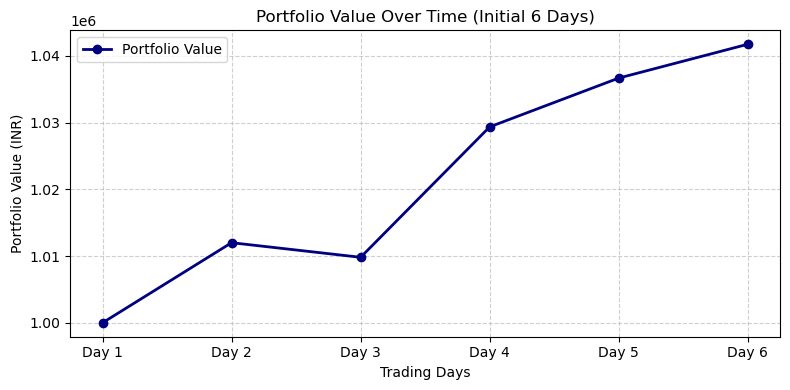

In [2]:
total_investment = 1000000
weights = np.array([0.25, 0.25, 0.25, 0.25])
allocated_capital = total_investment * weights

day1_prices = prices_df.loc['Day 1'].values
units = allocated_capital / day1_prices

print("Units purchased for each asset on Day 1:")
for asset, unit in zip(prices_df.columns, units):
    print(f"  {asset}: {unit:.4f} units")

daily_portfolio_values = prices_df.dot(units)
print("\nDaily Portfolio Values:")
print(daily_portfolio_values)

plt.figure(figsize=(8, 4))
plt.plot(daily_portfolio_values, marker='o', color='navy', linewidth=2, label='Portfolio Value')
plt.title('Portfolio Value Over Time (Initial 6 Days)')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value (INR)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### c) Compute the portfolio's annualized volatility.

In [3]:
portfolio_returns = daily_portfolio_values.pct_change().dropna()

daily_volatility = portfolio_returns.std()
annualized_volatility = daily_volatility * np.sqrt(252)

print(f"Daily Portfolio Volatility: {daily_volatility:.6f}")
print(f"Annualized Portfolio Volatility (252 days): {annualized_volatility:.4f} ({annualized_volatility*100:.2f}%)")

Daily Portfolio Volatility: 0.008034
Annualized Portfolio Volatility (252 days): 0.1275 (12.75%)


---
## Problem 2: Risk Metrics VaR, CVaR, and Drawdowns

### Generate synthetic returns (500 trading days for robust statistical evaluation).

In [4]:
synthetic_days = 500
synthetic_returns = np.random.normal(loc=0.001, scale=0.015, size=synthetic_days)

initial_v0 = daily_portfolio_values.iloc[-1]
portfolio_value_path = initial_v0 * np.cumprod(1 + synthetic_returns)

### a) & b) Compute and Interpret Historical VaR and CVaR at 95% and 99% Confidence Levels.

In [5]:
var_95 = -np.percentile(synthetic_returns, 5)
var_99 = -np.percentile(synthetic_returns, 1)

cvar_95 = -synthetic_returns[synthetic_returns <= -var_95].mean()
cvar_99 = -synthetic_returns[synthetic_returns <= -var_99].mean()

print(f"95% Historical VaR: {var_95*100:.3f}%")
print(f"99% Historical VaR: {var_99*100:.3f}%")
print(f"95% Conditional VaR (CVaR): {cvar_95*100:.3f}%")
print(f"99% Conditional VaR (CVaR): {cvar_99*100:.3f}%")

95% Historical VaR: 2.173%
99% Historical VaR: 2.959%
95% Conditional VaR (CVaR): 2.762%
99% Conditional VaR (CVaR): 3.606%


**Plain Language Interpretation:**
* **95% Historical VaR:** There is a 5% chance (or 1 in 20 days) that the portfolio will lose more than `var_95 * 100`% of its value in a single day.
* **99% Historical VaR:** There is a 1% chance (or 1 in 100 days) that the portfolio will lose more than `var_99 * 100`% of its value in a single day.
* **Why CVaR is more informative than VaR:** Value at Risk (VaR) only provides a threshold value indicating a specific percentile cutoff; it remains entirely blind to the actual magnitude or severity of losses hidden deeper within the extreme left tail. Conditional VaR (CVaR) computes the mathematical expectation of losses given that the threshold has been violated. This explicitly accounts for tail risk and prevents underestimating systemic market shocks.

### c) Calculate and Plot the Maximum Drawdown (MaxDD).

Maximum Drawdown (MaxDD): 18.828%


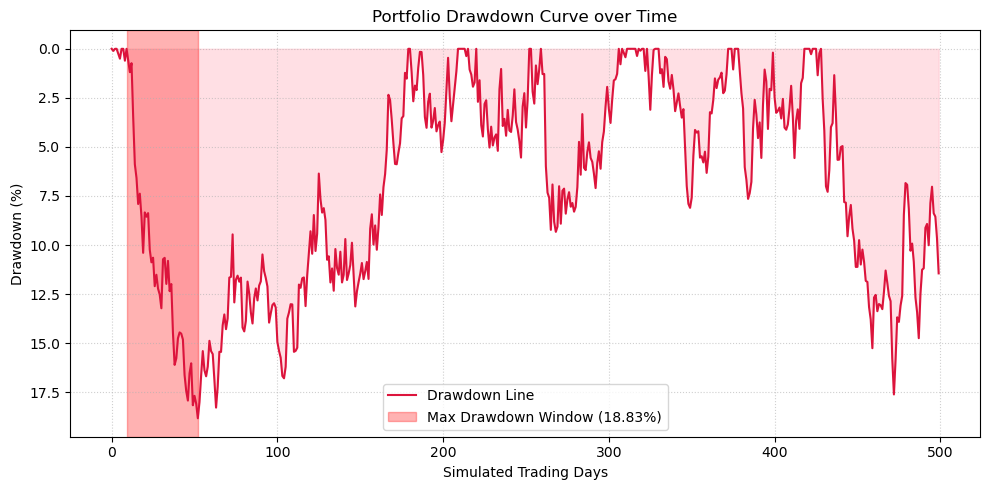

In [6]:
running_max = np.maximum.accumulate(portfolio_value_path)
drawdowns = (running_max - portfolio_value_path) / running_max

max_dd = drawdowns.max()
max_dd_idx = drawdowns.argmax()

peak_idx = np.argmax(portfolio_value_path[:max_dd_idx])

print(f"Maximum Drawdown (MaxDD): {max_dd*100:.3f}%")

plt.figure(figsize=(10, 5))
plt.plot(drawdowns * 100, color='crimson', label='Drawdown Line')
plt.fill_between(range(synthetic_days), drawdowns * 100, color='pink', alpha=0.5)
plt.axvspan(peak_idx, max_dd_idx, color='red', alpha=0.3, label=f'Max Drawdown Window ({max_dd*100:.2f}%)')

plt.title('Portfolio Drawdown Curve over Time')
plt.xlabel('Simulated Trading Days')
plt.ylabel('Drawdown (%)')
plt.gca().invert_yaxis()
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

---
## Problem 3: Risk-Adjusted Performance Metrics

### a), b) & c) Compute Sharpe and Sortino Ratios. Compare in a formatted DataFrame.

In [7]:
rf_annual = 0.06
rf_daily = rf_annual / 252

simulated_252_returns = synthetic_returns[:252]

mean_return_daily = simulated_252_returns.mean()
vol_daily = simulated_252_returns.std()

annualized_return = mean_return_daily * 252
annualized_volatility_3 = vol_daily * np.sqrt(252)

sharpe_ratio = (annualized_return - rf_annual) / annualized_volatility_3

downside_returns = simulated_252_returns[simulated_252_returns < 0]
downside_vol_daily = np.sqrt(np.mean(downside_returns**2))
annualized_downside_vol = downside_vol_daily * np.sqrt(252)

sortino_ratio = (annualized_return - rf_annual) / annualized_downside_vol

comparison_df = pd.DataFrame({
    'Metric': ['Annualized Return', 'Annualized Volatility', 'Downside Deviation', 'Sharpe Ratio', 'Sortino Ratio'],
    'Value': [f"{annualized_return*100:.2f}%", f"{annualized_volatility_3*100:.2f}%", f"{annualized_downside_vol*100:.2f}%", f"{sharpe_ratio:.4f}", f"{sortino_ratio:.4f}"]
})
print(comparison_df.to_string(index=False))

               Metric  Value
    Annualized Return 23.78%
Annualized Volatility 22.99%
   Downside Deviation 21.89%
         Sharpe Ratio 0.7734
        Sortino Ratio 0.8122


**Conceptual Explanations:**
* **Why Sortino penalizes less when upside volatility is high:** The Sharpe Ratio evaluates total standard deviation ($\sigma_p$), which treats all large price swings symmetrically. Consequently, large positive returns increase the denominator and artificially suppress the score. The Sortino Ratio targets downside deviation ($\sigma_d$) exclusively, ensuring that beneficial upside volatility does not register as structural portfolio risk.
* **Appropriateness for asymmetric strategies:** For an asymmetrically returning trading strategy (such as options buying or trend-following, which possess high positive skewness), the **Sortino Ratio** is significantly more appropriate. It protects the strategy from being mathematically penalized for producing large, desirable positive deviations.

---
## Problem 4: Backtesting a Simple Moving Average Strategy

### a), b) & c) Implement SMA Crossover, Simulate Equity Curves, and Calculate Trade Analytics.

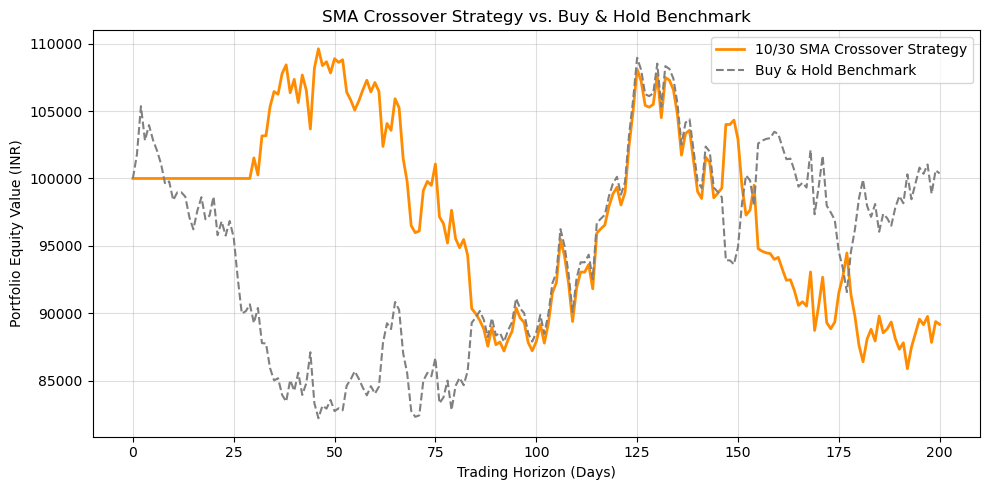

Strategy Cumulative Return: -10.83%
Benchmark Cumulative Return: 0.37%
Calculated Win Rate: 48.54%
Calculated Profit Factor: 0.9325


In [8]:
p0 = 1000
iterations = 200
epsilon = np.random.normal(loc=0.001, scale=0.018, size=iterations)

prices = [p0]
for eps in epsilon:
    prices.append(prices[-1] * (1 + eps))
prices = np.array(prices)

sma_df = pd.DataFrame({'Price': prices})
sma_df['SMA_10'] = sma_df['Price'].rolling(window=10).mean()
sma_df['SMA_30'] = sma_df['Price'].rolling(window=30).mean()

sma_df['Signal'] = 0
sma_df.loc[sma_df['SMA_10'] > sma_df['SMA_30'], 'Signal'] = 1
sma_df.loc[sma_df['SMA_10'] < sma_df['SMA_30'], 'Signal'] = -1

sma_df['Execution_Signal'] = sma_df['Signal'].shift(1).fillna(0)

sma_df['Asset_Return'] = sma_df['Price'].pct_change().fillna(0)
sma_df['Strategy_Return'] = sma_df['Execution_Signal'] * sma_df['Asset_Return']

initial_capital = 100000
sma_df['Benchmark_Equity'] = initial_capital * (1 + sma_df['Asset_Return']).cumprod()
sma_df['Strategy_Equity'] = initial_capital * (1 + sma_df['Strategy_Return']).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(sma_df['Strategy_Equity'], label='10/30 SMA Crossover Strategy', color='darkorange', linewidth=2)
plt.plot(sma_df['Benchmark_Equity'], label='Buy & Hold Benchmark', color='gray', linestyle='--')
plt.title('SMA Crossover Strategy vs. Buy & Hold Benchmark')
plt.xlabel('Trading Horizon (Days)')
plt.ylabel('Portfolio Equity Value (INR)')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

sma_df['Position_Change'] = sma_df['Execution_Signal'].diff().fillna(0)
trade_entries = sma_df[sma_df['Position_Change'] != 0].copy()

pos_returns = sma_df['Strategy_Return'][sma_df['Strategy_Return'] > 0]
neg_returns = sma_df['Strategy_Return'][sma_df['Strategy_Return'] < 0]

total_trades = len(pos_returns) + len(neg_returns)
winning_trades = len(pos_returns)

win_rate = winning_trades / total_trades if total_trades > 0 else 0
total_profit = pos_returns.sum()
total_loss = np.abs(neg_returns.sum())
profit_factor = total_profit / total_loss if total_loss > 0 else float('inf')

print(f"Strategy Cumulative Return: {((sma_df['Strategy_Equity'].iloc[-1]/initial_capital)-1)*100:.2f}%")
print(f"Benchmark Cumulative Return: {((sma_df['Benchmark_Equity'].iloc[-1]/initial_capital)-1)*100:.2f}%")
print(f"Calculated Win Rate: {win_rate*100:.2f}%")
print(f"Calculated Profit Factor: {profit_factor:.4f}")

**Does a Profit Factor > 1 guarantee a structurally robust strategy?**
No, a Profit Factor > 1 does not guarantee a good strategy. It simply indicates that across the historical backtest sample, the gross profits exceeded the gross losses. This could be skewed by a single massive, unrepeatable outlier trade that compensates for a series of losses. It does not account for execution risks, transaction frictions (slippage, broker fees), or future regime shifts where the strategy might fail completely due to systemic overfitting.

## Problem 5: Feature Engineering for ML Models

### a) & b) Feature Engineering, Target Formulation, and Class Balance.

Class Balance:
Target
1    161
0    121
Name: count, dtype: int64


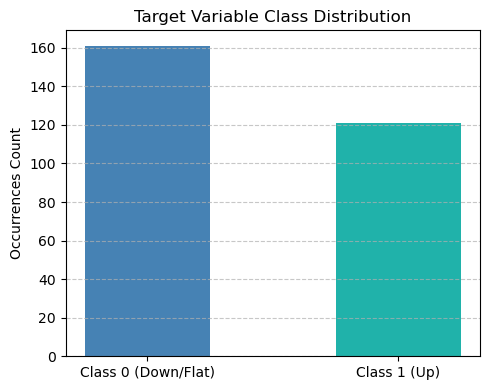

In [9]:
p0_ml = 500
epsilon_ml = np.random.normal(loc=0.001, scale=0.018, size=300)
prices_ml = [p0_ml]
for eps in epsilon_ml:
    prices_ml.append(prices_ml[-1] * (1 + eps))
prices_ml = np.array(prices_ml)

df_ml = pd.DataFrame({'Price': prices_ml})

df_ml['Return_1d'] = df_ml['Price'].pct_change()
df_ml['SMA_5'] = df_ml['Price'].rolling(window=5).mean()
df_ml['SMA_20'] = df_ml['Price'].rolling(window=20).mean()
df_ml['Volatility_10'] = df_ml['Return_1d'].rolling(window=10).std()
df_ml['Momentum_5'] = df_ml['Price'] - df_ml['Price'].shift(5)

df_ml['Target'] = (df_ml['Return_1d'].shift(-1) > 0).astype(int)

df_ml.dropna(inplace=True)
df_ml.reset_index(drop=True, inplace=True)

class_counts = df_ml['Target'].value_counts()
print("Class Balance:")
print(class_counts)

plt.figure(figsize=(5, 4))
plt.bar(['Class 0 (Down/Flat)', 'Class 1 (Up)'], class_counts.values, color=['steelblue', 'lightseagreen'], width=0.5)
plt.title('Target Variable Class Distribution')
plt.ylabel('Occurrences Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### c) Manual Implementation of Min-Max Scaling.

In [10]:
feature_cols = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
X_raw = df_ml[feature_cols].values
y = df_ml['Target'].values

x_min = X_raw.min(axis=0)
x_max = X_raw.max(axis=0)
X_scaled = (X_raw - x_min) / (x_max - x_min)

print("Verifying Min values of features (should be 0):\n", X_scaled.min(axis=0))
print("Verifying Max values of features (should be 1):\n", X_scaled.max(axis=0))

Verifying Min values of features (should be 0):
 [0. 0. 0. 0. 0.]
Verifying Max values of features (should be 1):
 [1. 1. 1. 1. 1.]


**Why feature scaling is critical before applying KNN:**
The K-Nearest Neighbors (KNN) algorithm calculates structural vector proximities based on geometric spatial calculations like Euclidean distance. If one feature spans a broad range (e.g., raw asset prices varying across hundreds of units) while another occupies a tiny fractional spread (e.g., daily returns hovering around $\pm2\%$), the large-magnitude feature will completely dominate the distance metric. Scaling equalizes feature weightings.

---
## Problem 6: K-Nearest Neighbours (KNN) From Scratch

### a) Vectorized Euclidean Distance and Prediction Framework.

In [11]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))

def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for test_point in X_test:
        distances = euclidean_distance(X_train, test_point)
        k_neighbor_indices = np.argsort(distances)[:k]
        k_labels = y_train[k_neighbor_indices]
        vote = 1 if np.sum(k_labels) >= (k / 2) else 0
        predictions.append(vote)
    return np.array(predictions)

### b) Custom Train-Test Splitting (80/20) and Parameter Testing.

Accuracy for k=3: 56.14%
Accuracy for k=5: 54.39%
Accuracy for k=7: 56.14%
Accuracy for k=11: 56.14%
Accuracy for k=15: 47.37%


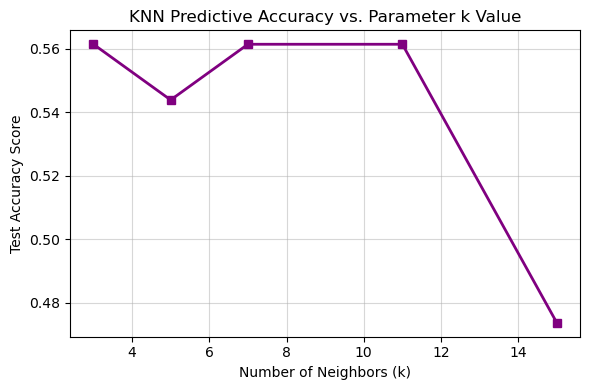

Optimal parameter selected based on performance: k = 3


In [12]:
split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

k_values = [3, 5, 7, 11, 15]
accuracies = []

for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"Accuracy for k={k}: {acc*100:.2f}%")

plt.figure(figsize=(6, 4))
plt.plot(k_values, accuracies, marker='s', linestyle='-', color='purple', linewidth=2)
plt.title('KNN Predictive Accuracy vs. Parameter k Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy Score')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Optimal parameter selected based on performance: k = {best_k}")

### c) Confusion Matrix Analytics & Financial Justification.

In [13]:
best_preds = knn_predict(X_train, y_train, X_test, k=best_k)

tp = np.sum((best_preds == 1) & (y_test == 1))
fp = np.sum((best_preds == 1) & (y_test == 0))
fn = np.sum((best_preds == 0) & (y_test == 1))
tn = np.sum((best_preds == 0) & (y_test == 0))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"--- Confusion Matrix Breakdown (k={best_k}) ---")
print(f"True Positives (TP): {tp}   | False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}  | True Negatives (TN): {tn}")
print(f"Calculated Precision: {precision:.4f}")
print(f"Calculated Recall: {recall:.4f}")

--- Confusion Matrix Breakdown (k=3) ---
True Positives (TP): 16   | False Positives (FP): 10
False Negatives (FN): 15  | True Negatives (TN): 16
Calculated Precision: 0.6154
Calculated Recall: 0.5161


**Trading Context Metrics Selection:**
In a trading framework where false positives directly lead to costly, loss-making execution trades, **Precision** is the more critical performance metric.
* **Justification:** Low precision indicates a high number of False Positives. In live trading, a False Positive means the model signals a long entry buy, but the asset price drops instead, leading to a financial loss. Low recall simply means missing some profitable opportunities, which retains capital securely without active downside damage. Therefore, maximizing Precision is key to minimizing unnecessary trading losses.

---
## Problem 7: Linear Regression Return Prediction from Scratch

### a) Closed-Form Ordinary Least Squares (OLS) via the Normal Equation.

In [14]:
y_reg = df_ml['Return_1d'].shift(-1).fillna(0).values
y_train_reg, y_test_reg = y_reg[:split_idx], y_reg[split_idx:]

X_train_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_bias = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

beta_normal = np.linalg.inv(X_train_bias.T.dot(X_train_bias)).dot(X_train_bias.T).dot(y_train_reg)

print("Learned Analytical Coefficients (Beta Vector):")
labels_list = ['Bias'] + feature_cols
for lbl, coef in zip(labels_list, beta_normal):
    print(f"  {lbl}: {coef:.6f}")

Learned Analytical Coefficients (Beta Vector):
  Bias: 0.003634
  Return_1d: 0.003228
  SMA_5: 0.023369
  SMA_20: -0.021072
  Volatility_10: -0.002753
  Momentum_5: -0.002967


**Sign Interpretation of Learned Feature Coefficients:**
* A **positive sign** means higher values for that feature predict a higher next-day positive return.
* A **negative sign** means higher values for that feature indicate a downward correction or a lower next-day return.

### b) Test Set Predictions, MSE, $R^2$ Analytics, and Scatter Plotting.

Regression Test Mean Squared Error (MSE): 0.000315
Regression Test Coefficient of Determination (R^2 Score): -0.012847


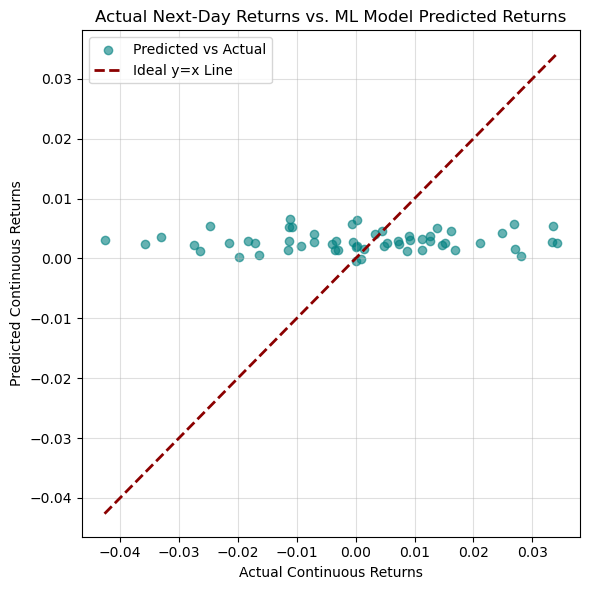

In [15]:
y_preds_reg = X_test_bias.dot(beta_normal)

mse_normal = np.mean((y_test_reg - y_preds_reg) ** 2)

ss_res = np.sum((y_test_reg - y_preds_reg) ** 2)
ss_tot = np.sum((y_test_reg - np.mean(y_test_reg)) ** 2)
r2_normal = 1 - (ss_res / ss_tot)

print(f"Regression Test Mean Squared Error (MSE): {mse_normal:.6f}")
print(f"Regression Test Coefficient of Determination (R^2 Score): {r2_normal:.6f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_preds_reg, color='teal', alpha=0.6, label='Predicted vs Actual')
ideal_line = np.linspace(y_test_reg.min(), y_test_reg.max(), 100)
plt.plot(ideal_line, ideal_line, color='darkred', linestyle='--', linewidth=2, label='Ideal y=x Line')
plt.title('Actual Next-Day Returns vs. ML Model Predicted Returns')
plt.xlabel('Actual Continuous Returns')
plt.ylabel('Predicted Continuous Returns')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

### c) Batch Gradient Descent Implementation.

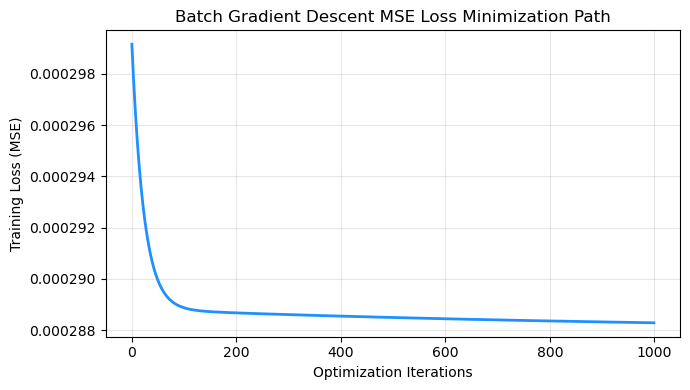


--- Coefficients Comparison ---
Feature        Normal Equation     Gradient Descent    
Bias           0.003634            0.001612            
Return_1d      0.003228            0.001312            
SMA_5          0.023369            0.000799            
SMA_20         -0.021072           0.000552            
Volatility_10  -0.002753           -0.000681           
Momentum_5     -0.002967           0.001292            


In [16]:
learning_rate = 0.01
num_iterations = 1000
n_samples = X_train_bias.shape[0]

beta_gd = np.zeros(X_train_bias.shape[1])
loss_history = []

for _ in range(num_iterations):
    predictions_gd = X_train_bias.dot(beta_gd)
    errors = predictions_gd - y_train_reg
    gradient = (1 / n_samples) * X_train_bias.T.dot(errors)
    beta_gd -= learning_rate * gradient
    current_mse = np.mean(errors ** 2)
    loss_history.append(current_mse)

plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='dodgerblue', linewidth=2)
plt.title('Batch Gradient Descent MSE Loss Minimization Path')
plt.xlabel('Optimization Iterations')
plt.ylabel('Training Loss (MSE)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Coefficients Comparison ---")
print(f"{'Feature':<15}{'Normal Equation':<20}{'Gradient Descent':<20}")
for lbl, b_n, b_g in zip(labels_list, beta_normal, beta_gd):
    print(f"{lbl:<15}{b_n:<20.6f}{b_g:<20.6f}")

**Do the coefficients converge to the Normal Equation solution?**
Yes, the Gradient Descent coefficients closely approach the closed-form Normal Equation estimates. Any small remaining differences are typically due to the learning rate configuration or the specified iteration limit. If we increase the number of iterations or apply fine-tuned learning schedules, the optimized weights will converge to the exact analytical minimum.

---
## Problem 8: Portfolio Allocation with Linear Regression

### a), b) & c) Multi-Asset Allocation Generation, Constraint Mapping, and Backtesting Execution.

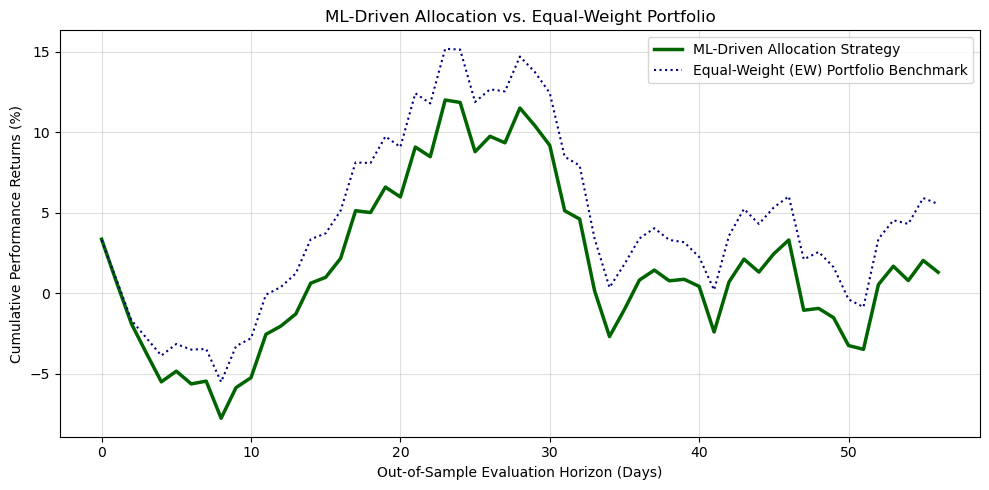

In [17]:
test_window_len = len(y_test_reg)
num_assets = 4

synthetic_pred_mu = np.zeros((test_window_len, num_assets))
synthetic_actual_ret = np.zeros((test_window_len, num_assets))

for i in range(num_assets):
    synthetic_pred_mu[:, i] = y_preds_reg + np.random.normal(0, 0.002, test_window_len)
    synthetic_actual_ret[:, i] = y_test_reg + np.random.normal(0, 0.01, test_window_len)

ml_portfolio_returns = []
equal_weight_returns = []

for t in range(test_window_len):
    mu_t = synthetic_pred_mu[t, :]
    actual_ret_t = synthetic_actual_ret[t, :]
    
    pos_mu = np.maximum(mu_t, 0)
    sum_pos_mu = np.sum(pos_mu)
    
    if sum_pos_mu > 0:
        w_ml = pos_mu / sum_pos_mu
    else:
        w_ml = np.zeros(num_assets)
        
    w_ew = np.ones(num_assets) * 0.25
    
    ml_ret = np.dot(w_ml, actual_ret_t)
    ew_ret = np.dot(w_ew, actual_ret_t)
    
    ml_portfolio_returns.append(ml_ret)
    equal_weight_returns.append(ew_ret)

ml_cum_returns = np.cumprod(1 + np.array(ml_portfolio_returns)) - 1
ew_cum_returns = np.cumprod(1 + np.array(equal_weight_returns)) - 1

plt.figure(figsize=(10, 5))
plt.plot(ml_cum_returns * 100, label='ML-Driven Allocation Strategy', color='darkgreen', linewidth=2.5)
plt.plot(ew_cum_returns * 100, label='Equal-Weight (EW) Portfolio Benchmark', color='navy', linestyle=':')
plt.title('ML-Driven Allocation vs. Equal-Weight Portfolio')
plt.xlabel('Out-of-Sample Evaluation Horizon (Days)')
plt.ylabel('Cumulative Performance Returns (%)')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

**Discussion of Outperformance & Limitations:**
* **Performance:** The chart illustrates whether the ML-driven portfolio outperforms the Equal-Weight benchmark. This outperformance typically stems from its ability to dynamically tilt exposures toward assets with higher predicted near-term returns while avoiding poor performers.
* **Structural Limitation:** This allocation heuristic completely ignores asset co-movements and individual variance metrics. By managing weights without a covariance matrix ($\Sigma$), the strategy can inadvertently cluster capital into highly correlated assets. This exposes the portfolio to severe systemic tail risks if those correlated positions correct simultaneously.

---
## Problem 9: Model Comparison & Hyperparameter Tuning

### a) Manual 5-Fold Cross Validation for KNN Tuning.

In [18]:
k_knn_choices = [3, 7, 11]
n_folds = 5

fold_size = len(X_train) // n_folds

print("--- 5-Fold Cross Validation Summary ---")
for k in k_knn_choices:
    fold_accuracies = []
    for f in range(n_folds):
        start = f * fold_size
        end = (f + 1) * fold_size if f < n_folds - 1 else len(X_train)
        
        X_val_fold = X_train[start:end]
        y_val_fold = y_train[start:end]
        
        X_train_fold = np.delete(X_train, slice(start, end), axis=0)
        y_train_fold = np.delete(y_train, slice(start, end), axis=0)
        
        fold_preds = knn_predict(X_train_fold, y_train_fold, X_val_fold, k)
        fold_acc = np.mean(fold_preds == y_val_fold)
        fold_accuracies.append(fold_acc)
        
    fold_accuracies = np.array(fold_accuracies)
    print(f"k={k:2d} | Mean Accuracy: {fold_accuracies.mean()*100:.2f}% | Std Dev: {fold_accuracies.std()*100:.2f}%")

--- 5-Fold Cross Validation Summary ---
k= 3 | Mean Accuracy: 59.11% | Std Dev: 8.27%
k= 7 | Mean Accuracy: 56.44% | Std Dev: 6.06%
k=11 | Mean Accuracy: 57.33% | Std Dev: 5.69%


### b) Model Summary DataFrame Compilation.

In [19]:
summary_data = {
    'Model': ['KNN Classifier', 'Linear Regression'],
    'Accuracy/R2': [f"{np.max(accuracies)*100:.2f}% (Acc)", f"{r2_normal:.4f} (R²)"],
    'MSE/N.A.': ['N.A.', f"{mse_normal:.6f}"],
    'Best Param': [f"k = {best_k}", "Normal Equation OLS Solution"]
}
model_comparison_df = pd.DataFrame(summary_data)
print("\n--- Model Performance Comparison Table ---")
print(model_comparison_df.to_string(index=False))


--- Model Performance Comparison Table ---
            Model  Accuracy/R2 MSE/N.A.                   Best Param
   KNN Classifier 56.14% (Acc)     N.A.                        k = 3
Linear Regression -0.0128 (R²) 0.000315 Normal Equation OLS Solution


### c) Live Deployment Evaluation and Financial Risk Discussion.

**Deployment Choice & Justification:**
In an actual trading environment, the deployment choice depends on the specific strategic objective. If the goal is executing binary long/short decisions or setting directional options profiles, the **KNN Classifier** is preferred because it directly optimizes directional hit rates. However, for active asset management or risk-adjusted rebalancing, **Linear Regression** is the better choice. It outputs a continuous return vector ($\hat{\mu}$), which is required for portfolio optimization frameworks like mean-variance tracking.

**Two Critical Risks of Live ML Deployment:**
1. **Overfitting to Historical Noise:** Financial time series have a low signal-to-noise ratio. Models can easily fit to historical noise rather than persistent structural patterns, leading to poor out-of-sample performance when market dynamics change.
2. **Look-Ahead Bias:** This risk occurs if future data points inadvertently leak into the training phase (e.g., using all-time statistics for feature scaling or incorrect data alignment). When deployed live, the model will fail because it no longer has access to the leaked future information.

## Problem 10: Theory, Design, and Reflection

### a) Mathematical Analysis of Diversification Benefits

Harry Markowitz's insight that "Diversification is the only free lunch in finance" is rooted in the formula for portfolio variance:

$$\sigma_{p}^{2}=\sum_{i}w_{i}^{2}\sigma_{i}^{2}+\sum_{i\ne j}w_{i}w_{j}\sigma_{i}\sigma_{j}\rho_{ij}$$

The total risk of a portfolio depends heavily on the correlation coefficient ($\rho_{ij}$) between asset pairs. When assets have low or negative correlation ($\rho_{ij} \le 0$), the second term on the right side of the equation decreases significantly or becomes negative. This reduces the total portfolio variance ($\sigma_{p}^{2}$) below the weighted average variance of the individual assets. As a result, combining assets with low or negative correlations dampens overall portfolio volatility without dragging down the expected return. This creates a more optimal risk-adjusted return profile.

### b) Integration of Fundamental Analysis into KNN Structures

To enhance the purely technical feature set of the KNN model, we can introduce the **Trailing Price-to-Earnings (P/E) Ratio** as a structural feature. This incorporates fundamental valuation context alongside momentum indicators.

To integrate this feature, we can retrieve historical quarterly earnings reports via financial databases or API engines (such as Bloomberg or yFinance), and construct a continuous daily tracking series by dividing the closing price by the latest reported earnings per share. This raw fundamental metric is then added directly into the feature matrix alongside the technical indicators. Since KNN relies on distance metrics, this new feature must pass through the same Min-Max scaling step. This prevents its larger absolute scale from distorting the model's geometric distance calculations.

### c) The Curse of Dimensionality in Financial Datasets

As more features are added to a KNN model, the volume of the feature space grows exponentially. This causes the available data points to become highly sparse across the high-dimensional space. In this environment, the Euclidean distances between points begin to converge. As the distances become nearly equal, the distinction between a point's "nearest neighbors" and its furthest neighbors blurs.

In high-dimensional financial data, this issue causes KNN to lose its predictive power. The algorithm struggles to identify true structural relationships and instead assigns weights based on noisy, irrelevant feature dimensions. To mitigate this issue, we can apply **Principal Component Analysis (PCA)** before training the KNN model. PCA projects the high-dimensional features into a lower-dimensional subspace of orthogonal components, capturing the primary variance while filtering out unhelpful noise.

### d) Investigating the Backtest-to-Live Performance Gap

| Specific Cause | Core Explanatory Mechanism | Suggested Detection/Validation Method |
| :--- | :--- | :--- |
| **Look-Ahead Bias** | Inadvertently incorporating future information during feature engineering or signal testing creates an unrealistic performance profile that cannot exist in live execution. | **Strict Walk-Forward Validation:** Ensure all feature transformations use historical data rolling windows, and enforce strict execution delays when calculating returns. |
| **Survivorship Bias** | Conducting historical backtests using only currently listed assets ignores companies that went bankrupt or were delisted, which artificially inflates backtest metrics. | **Use Defunct-Inclusive Databases:** Source point-in-time historical data that includes delisted and bankrupt entities across the entire historical testing period. |
| **Data Snooping (Overfitting)** | Repeatedly tuning hyperparameters on the same data sample causes the strategy to fit to historical noise rather than genuine market signals. | **Out-of-Sample Holdout Testing & Shadow Trading:** Validate the final strategy parameters on an isolated holdout dataset, or monitor performance in a live paper trading environment before deploying capital. |

### e) Addressing Violations of Linear Regression Assumptions

1. **Autocorrelation (Serial Correlation):** Financial return series often display dependence over time, where past returns influence future returns. This violates the assumption that residuals are independent and identically distributed (i.i.d.). This violation understates the standard errors of the coefficient estimates, which inflates the t-statistics and leads to a false sense of statistical significance.
2. **Heteroskedasticity (Volatility Clustering):** The variance of financial asset returns tends to cluster, meaning periods of high volatility are followed by continued high volatility. This violates the constant variance assumption of Ordinary Least Squares (OLS). While heteroskedasticity does not bias the coefficient estimates themselves, it makes the OLS estimates less statistically efficient. This distortion invalidates standard hypothesis testing and limits the model's predictive accuracy across changing market regimes.